# Analysis of Pmpp when the Irradiance and Temperature Values Vary in Steps

In [87]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [88]:
df = pd.read_csv('../03_data/PV_results.csv')

### G (irradiance) – Histogram + KDE


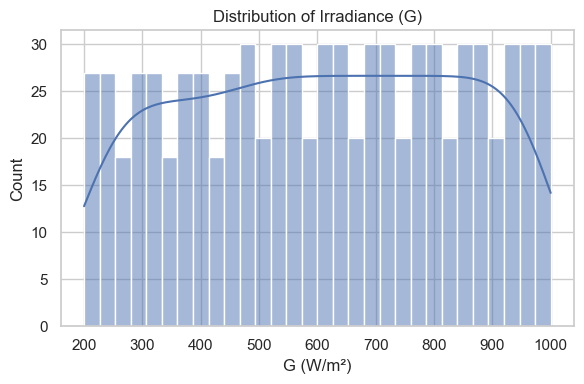

In [89]:
plt.figure(figsize=(6, 4))
sns.histplot(df['G'], bins=30, kde=True)
plt.title('Distribution of Irradiance (G)')
plt.xlabel('G (W/m²)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Temp – Histogram + KDE

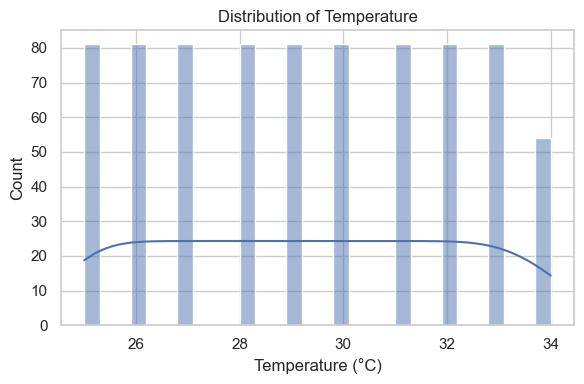

In [90]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Temp'], bins=30, kde=True)
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Vmpp / Impp – Histograms

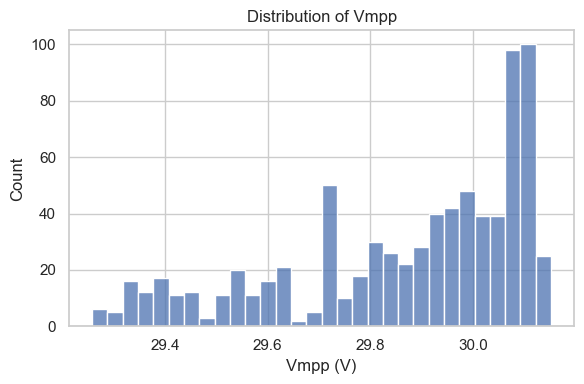

In [91]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Vmpp'], bins=30, kde=False)
plt.title('Distribution of Vmpp')
plt.xlabel('Vmpp (V)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


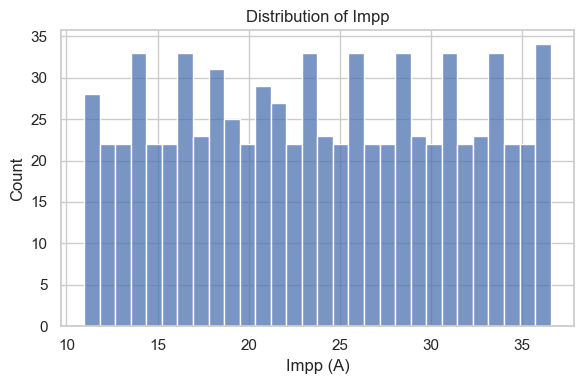

In [92]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Impp'], bins=30, kde=False)
plt.title('Distribution of Impp')
plt.xlabel('Impp (A)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Pmpp – Histogram

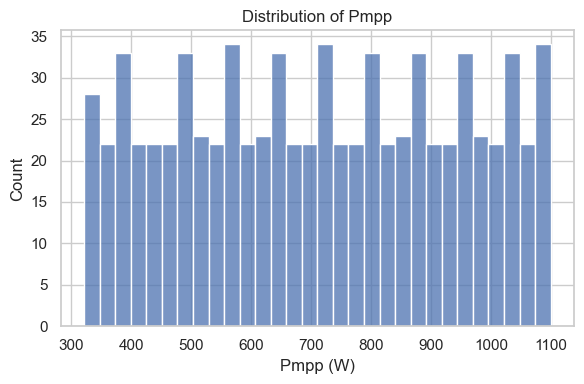

In [93]:
plt.figure(figsize=(6, 4))
sns.histplot(df['Pmpp'], bins=30, kde=False)
plt.title('Distribution of Pmpp')
plt.xlabel('Pmpp (W)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Correlation Heatmap

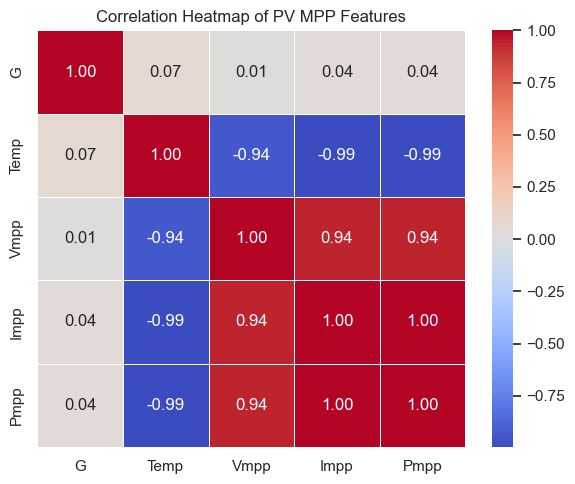

In [94]:
corr_features = ['G', 'Temp', 'Vmpp', 'Impp', 'Pmpp']
corr_matrix = df[corr_features].corr()   # Pearson correlation

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of PV MPP Features')
plt.tight_layout()
plt.show()

### Pmpp vs G - Scatter Plot

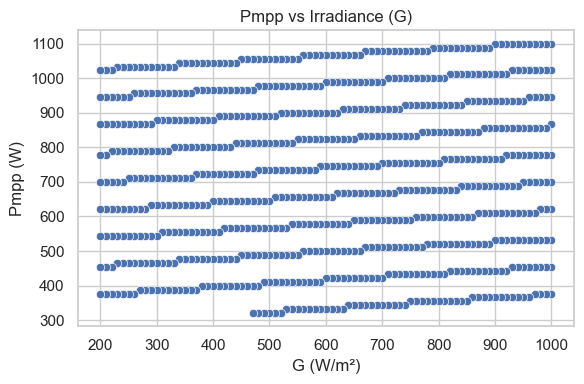

In [95]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='G', y='Pmpp')
plt.title('Pmpp vs Irradiance (G)')
plt.xlabel('G (W/m²)')
plt.ylabel('Pmpp (W)')
plt.tight_layout()
plt.show()


### Pmpp vs Temp - Scatter Plot

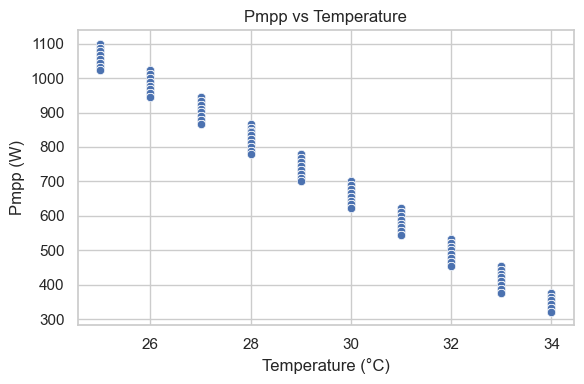

In [96]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Temp', y='Pmpp')
plt.title('Pmpp vs Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Pmpp (W)')
plt.tight_layout()
plt.show()


### Pmpp Vs Vmpp - Scatter Plot

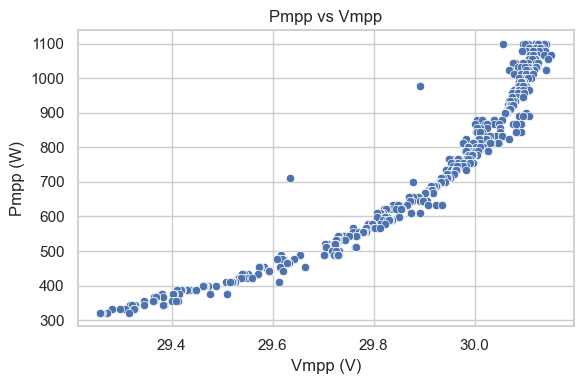

In [97]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Vmpp', y='Pmpp')
plt.title('Pmpp vs Vmpp')
plt.xlabel('Vmpp (V)')
plt.ylabel('Pmpp (W)')
plt.tight_layout()
plt.show()


### Pmpp vs Impp - Scatter Plot

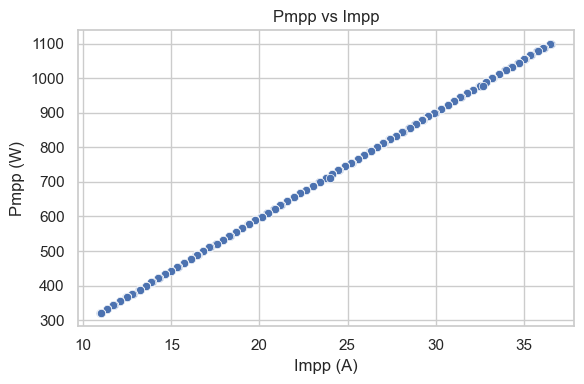

In [98]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Impp', y='Pmpp')
plt.title('Pmpp vs Impp')
plt.xlabel('Impp (A)')
plt.ylabel('Pmpp (W)')
plt.tight_layout()
plt.show()



### G vs Temp - Scatter Plot

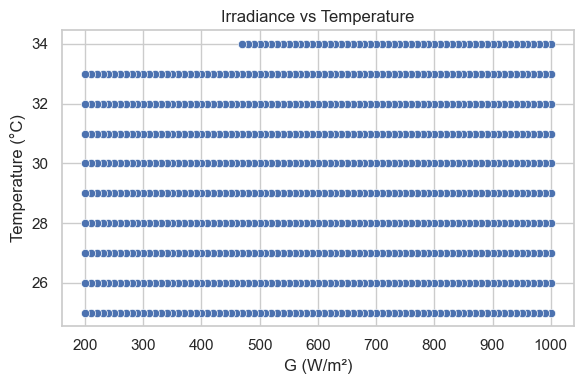

In [99]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='G', y='Temp')
plt.title('Irradiance vs Temperature')
plt.xlabel('G (W/m²)')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()


### 2D Heatmap of G Temp and Pmpp

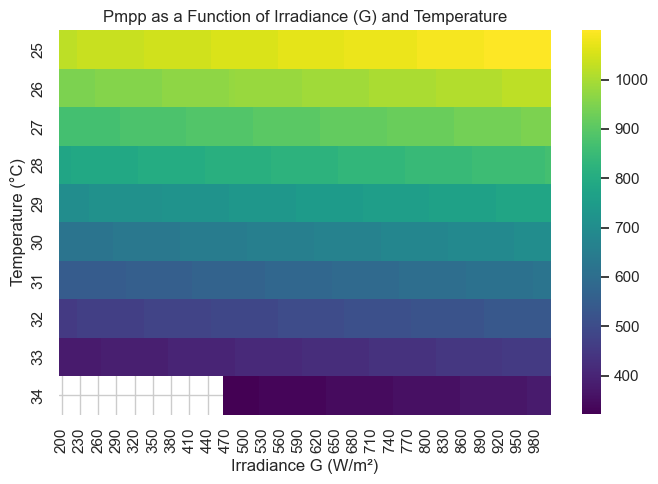

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create pivot table: rows = Temp, columns = G, values = mean Pmpp
heatmap_data = df.pivot_table(
    index='Temp',
    columns='G',
    values='Pmpp',
    aggfunc='mean'
)

plt.figure(figsize=(7, 5))
sns.heatmap(heatmap_data, cmap='viridis')
plt.title('Pmpp as a Function of Irradiance (G) and Temperature')
plt.xlabel('Irradiance G (W/m²)')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()


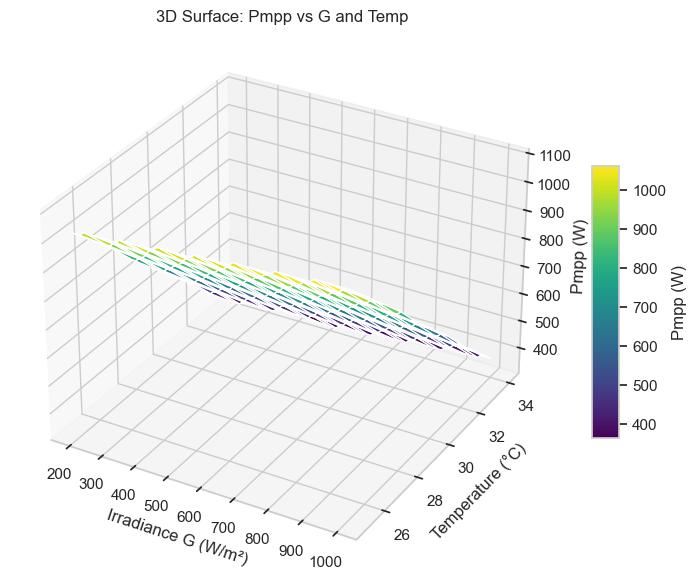

In [101]:
import numpy as np

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)

# Use same pivot as heatmap
surface_data = df.pivot_table(
    index='Temp',
    columns='G',
    values='Pmpp',
    aggfunc='mean'
)

G_vals = surface_data.columns.values   # x-axis (G)
T_vals = surface_data.index.values     # y-axis (Temp)
G_grid, T_grid = np.meshgrid(G_vals, T_vals)
P_grid = surface_data.values           # z-axis (Pmpp)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(G_grid, T_grid, P_grid, cmap='viridis')

ax.set_title('3D Surface: Pmpp vs G and Temp')
ax.set_xlabel('Irradiance G (W/m²)')
ax.set_ylabel('Temperature (°C)')
ax.set_zlabel('Pmpp (W)')

fig.colorbar(surf, shrink=0.5, aspect=10, label='Pmpp (W)')

plt.tight_layout()
plt.show()


### Box Plots for Outlier Detection

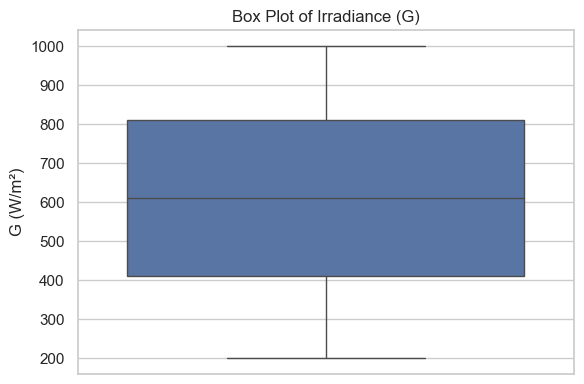

In [103]:

plt.figure(figsize=(6, 4))
sns.boxplot(y=df['G'])
plt.title('Box Plot of Irradiance (G)')
plt.ylabel('G (W/m²)')
plt.tight_layout()
plt.show()

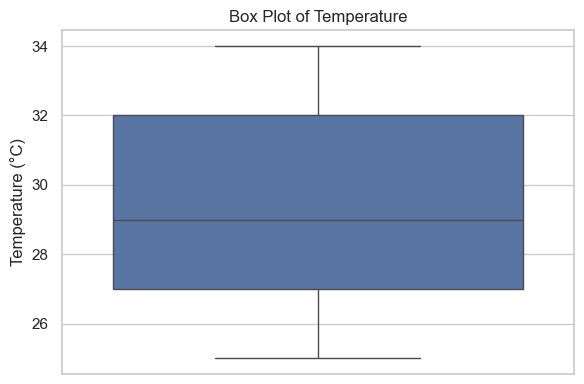

In [106]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Temp'])
plt.title('Box Plot of Temperature')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

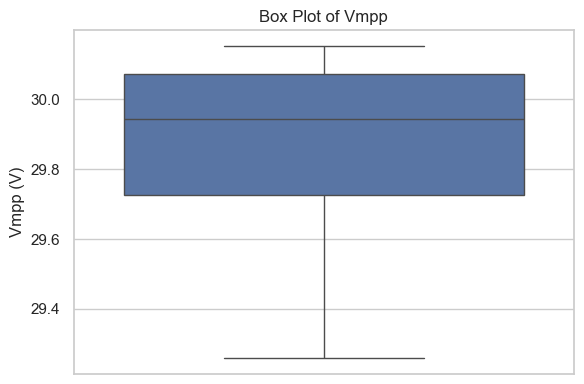

In [107]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Vmpp'])
plt.title('Box Plot of Vmpp')
plt.ylabel('Vmpp (V)')
plt.tight_layout()
plt.show()

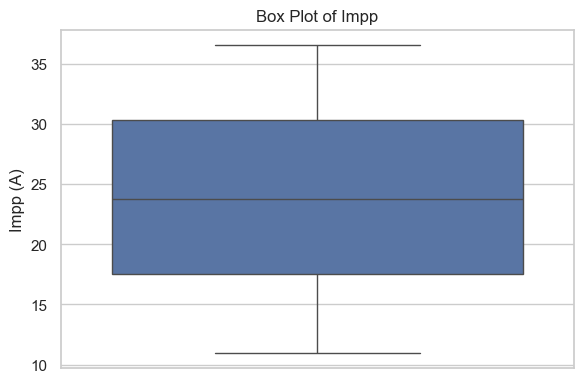

In [108]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Impp'])
plt.title('Box Plot of Impp')
plt.ylabel('Impp (A)')
plt.tight_layout()
plt.show()

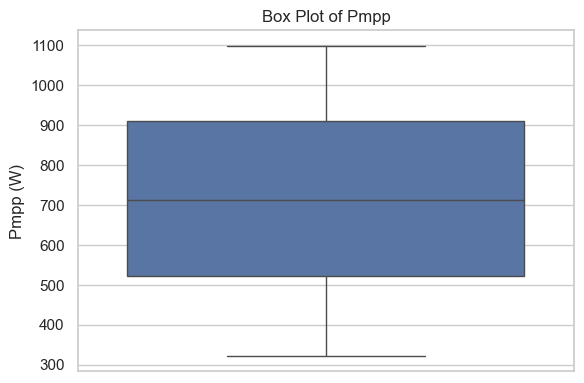

In [109]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['Pmpp'])
plt.title('Box Plot of Pmpp')
plt.ylabel('Pmpp (W)')
plt.tight_layout()
plt.show()

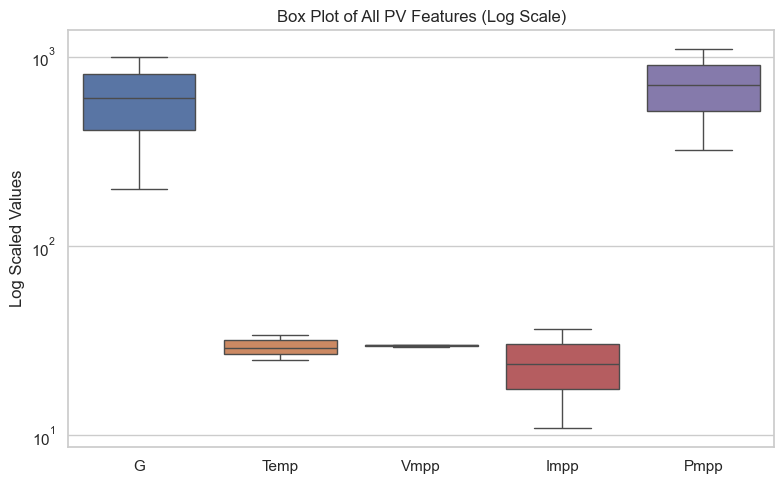

In [110]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['G', 'Temp', 'Vmpp', 'Impp', 'Pmpp']])
plt.yscale('log')
plt.title('Box Plot of All PV Features (Log Scale)')
plt.ylabel('Log Scaled Values')
plt.tight_layout()
plt.show()
